# Result Analysis

En este apartado analizaremos los resultados de los experimentos.

In [18]:
import pandas as pd
import numpy as np

# 1. Definimos los datos manualmente basándonos en tu mensaje
data = [
    {"ID Exp.": "EXP-CNN-01",       "Acc. Medio": 0.6917, "IC Inf (95%)": 0.6000, "IC Sup (95%)": 0.7800},
    {"ID Exp.": "EXP-CNN-02",       "Acc. Medio": 0.7039, "IC Inf (95%)": 0.6100, "IC Sup (95%)": 0.7900},
    {"ID Exp.": "EXP-CNN-03",       "Acc. Medio": 0.9551, "IC Inf (95%)": 0.9250, "IC Sup (95%)": 0.9800},
    {"ID Exp.": "EXP-CNN-04",       "Acc. Medio": 0.9103, "IC Inf (95%)": 0.8650, "IC Sup (95%)": 0.9500},
    {"ID Exp.": "EXP-LSTM-01",      "Acc. Medio": 0.8095, "IC Inf (95%)": 0.7300, "IC Sup (95%)": 0.8800},
    {"ID Exp.": "EXP-LSTM-01-deep", "Acc. Medio": 0.7808, "IC Inf (95%)": 0.7000, "IC Sup (95%)": 0.8600},
    {"ID Exp.": "EXP-LSTM-02",      "Acc. Medio": 0.8800, "IC Inf (95%)": 0.8200, "IC Sup (95%)": 0.9400},
    {"ID Exp.": "EXP-LSTM-03",      "Acc. Medio": 0.8901, "IC Inf (95%)": 0.8450, "IC Sup (95%)": 0.9300},
    {"ID Exp.": "EXP-LSTM-04",      "Acc. Medio": 0.9800, "IC Inf (95%)": 0.9600, "IC Sup (95%)": 0.9950},
    {"ID Exp.": "EXP-Bi-LSTM-01",   "Acc. Medio": 0.7700, "IC Inf (95%)": 0.6900, "IC Sup (95%)": 0.8500},
    {"ID Exp.": "EXP-Bi-LSTM-02",   "Acc. Medio": 0.9000, "IC Inf (95%)": 0.8400, "IC Sup (95%)": 0.9500},
    {"ID Exp.": "EXP-Bi-LSTM-03",   "Acc. Medio": 0.8746, "IC Inf (95%)": 0.8250, "IC Sup (95%)": 0.9200},
    {"ID Exp.": "EXP-Bi-LSTM-04",   "Acc. Medio": 0.9701, "IC Inf (95%)": 0.9450, "IC Sup (95%)": 0.9900},
    {"ID Exp.": "EXP-ST-GCN-01",    "Acc. Medio": 0.8287, "IC Inf (95%)": 0.7500, "IC Sup (95%)": 0.9100},
    {"ID Exp.": "EXP-ST-GCN-02",    "Acc. Medio": 0.8654, "IC Inf (95%)": 0.8150, "IC Sup (95%)": 0.9150},
]

# 2. Creamos el DataFrame
df_resultados = pd.DataFrame(data)

# Mostramos la tabla en pantalla
print("=== Tabla de Resultados ===")
print(df_resultados)

=== Tabla de Resultados ===
             ID Exp.  Acc. Medio  IC Inf (95%)  IC Sup (95%)
0         EXP-CNN-01      0.6917         0.600         0.780
1         EXP-CNN-02      0.7039         0.610         0.790
2         EXP-CNN-03      0.9551         0.925         0.980
3         EXP-CNN-04      0.9103         0.865         0.950
4        EXP-LSTM-01      0.8095         0.730         0.880
5   EXP-LSTM-01-deep      0.7808         0.700         0.860
6        EXP-LSTM-02      0.8800         0.820         0.940
7        EXP-LSTM-03      0.8901         0.845         0.930
8        EXP-LSTM-04      0.9800         0.960         0.995
9     EXP-Bi-LSTM-01      0.7700         0.690         0.850
10    EXP-Bi-LSTM-02      0.9000         0.840         0.950
11    EXP-Bi-LSTM-03      0.8746         0.825         0.920
12    EXP-Bi-LSTM-04      0.9701         0.945         0.990
13     EXP-ST-GCN-01      0.8287         0.750         0.910
14     EXP-ST-GCN-02      0.8654         0.815         0.

In [19]:
df_resultados.to_csv("../results/resultados_exp_bootstrap.csv", index=False)
print("\n Guardado como 'resultados_tesis_bootstrap.csv'")


 Guardado como 'resultados_tesis_bootstrap.csv'


**Carga del fichero con los resultados**

In [20]:
df_resultados = pd.read_csv("../results/resultados_exp_bootstrap.csv")
df_resultados.head()

,ID Exp.,Acc. Medio,IC Inf (95%),IC Sup (95%)
0,EXP-CNN-01,0.6917,0.600,0.78
1,EXP-CNN-02,0.7039,0.610,0.79
2,EXP-CNN-03,0.9551,0.925,0.98
3,EXP-CNN-04,0.9103,0.865,0.95
4,EXP-LSTM-01,0.8095,0.730,0.88


## A. Establecimiento de la Línea Base (Baseline)
*¿Cuáles son las puntuaciones mínimas que podemos alcanzar con el modelo más básico?*

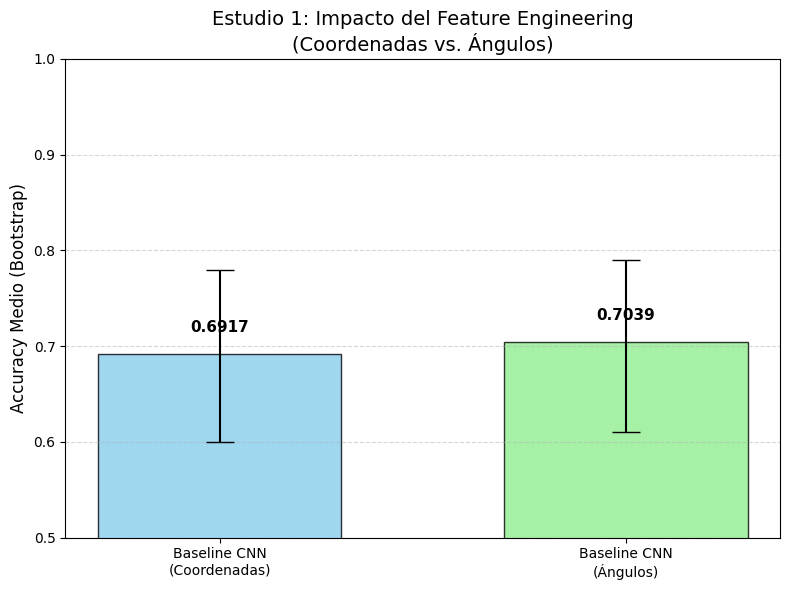

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


# Seleccionamos solo los experimentos del Estudio 1
ids_interes = ['EXP-CNN-01', 'EXP-CNN-02'] 

study_df = df_resultados[df_resultados['ID Exp.'].isin(ids_interes)].copy()

# Asignamos nombres legibles para el eje X
nombres_legibles = {
    'EXP-CNN-01': 'Baseline CNN\n(Coordenadas)',
    'EXP-CNN-02': 'Baseline CNN\n(Ángulos)'
}
study_df['Nombre'] = study_df['ID Exp.'].map(nombres_legibles)

# CALCULAMOS LOS ERRORES RELATIVOS
study_df['err_down'] = study_df['Acc. Medio'] - study_df['IC Inf (95%)']
study_df['err_up']   = study_df['IC Sup (95%)'] - study_df['Acc. Medio']

# Preparamos la matriz de errores (2, N) que pide matplotlib
yerr = [study_df['err_down'].values, study_df['err_up'].values]

# Gráfico de barras con barras de error
plt.figure(figsize=(8, 6))

# Colores diferenciados
colors = ['skyblue', 'lightgreen']

bars = plt.bar(
    study_df['Nombre'], 
    study_df['Acc. Medio'], 
    yerr=yerr,          
    capsize=10,         
    color=colors, 
    edgecolor='black',
    alpha=0.8,
    width=0.6
)


plt.ylabel('Accuracy Medio (Bootstrap)', fontsize=12)
plt.title('Estudio 1: Impacto del Feature Engineering\n(Coordenadas vs. Ángulos)', fontsize=14)
plt.ylim(0.5, 1.0) # Ajustamos zoom 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos el valor numérico encima de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

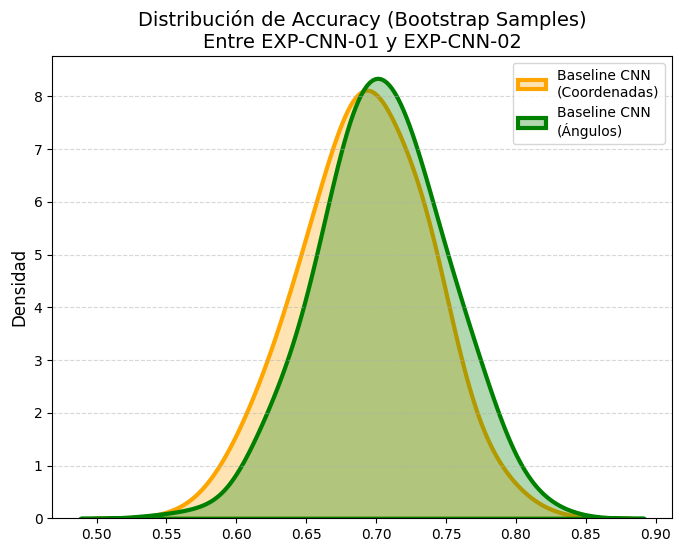

In [22]:
PATH = '../results'
FILE_NAME_CNN_01 = 'bootstrap_accuracies_exp_cnn_01.npy'
FILE_NAME_CNN_02 = 'bootstrap_accuracies_exp_cnn_02.npy'

ba_exp_cnn_01 = np.load(os.path.join(PATH, FILE_NAME_CNN_01))
ba_exp_cnn_02 = np.load(os.path.join(PATH, FILE_NAME_CNN_02))

# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(ba_exp_cnn_01, color='orange', lw=3, label=nombres_legibles['EXP-CNN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_02, color='green', lw=3, label=nombres_legibles['EXP-CNN-02'], bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre EXP-CNN-01 y EXP-CNN-02', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

No se observan grandes diferencias en los resultados. Podemos establecer como punto de partida un accuracy promedio del 70 %.

## B. Exploración de Modelos Recurrentes (RNNs)
*¿Conseguimos mejorar el rendimiento del modelo con LSTMs?*

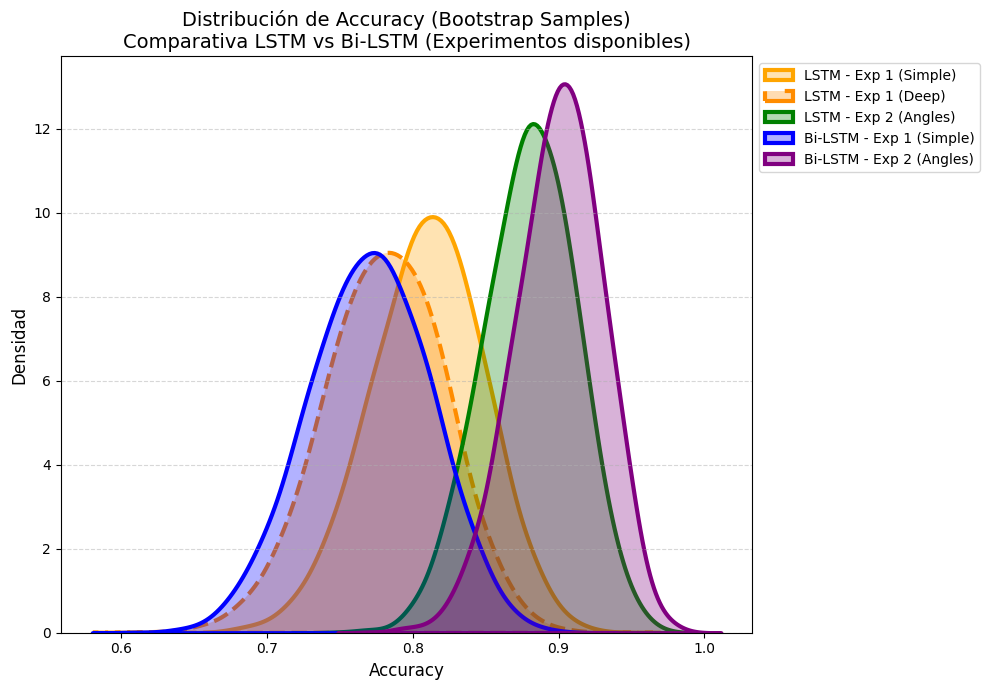

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de experimentos disponibles
ba_exp_lstm_01 = np.load('../results/bootstrap_accuracies_exp_LSTM_01.npy') 
ba_exp_lstm_01_deep = np.load('../results/bootstrap_accuracies_exp_LSTM_01-deep.npy') 
ba_exp_lstm_02 = np.load('../results/bootstrap_accuracies_exp_LSTM_02.npy')
ba_exp_bi_lstm_01 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_01.npy')
ba_exp_bi_lstm_02 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_02.npy')

nombres_legibles_lstm = {
    'EXP-LSTM-01':      'LSTM - Exp 1 (Simple)',
    'EXP-LSTM-01-deep': 'LSTM - Exp 1 (Deep)',
    'EXP-LSTM-02':      'LSTM - Exp 2 (Angles)',
    'EXP-Bi-LSTM-01':   'Bi-LSTM - Exp 1 (Simple)',
    'EXP-Bi-LSTM-02':   'Bi-LSTM - Exp 2 (Angles)',
}

plt.figure(figsize=(10, 7))

# Curvas LSTM
sns.kdeplot(ba_exp_lstm_01, color='orange', lw=3, label=nombres_legibles_lstm['EXP-LSTM-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_lstm_01_deep, color='darkorange', lw=3, label=nombres_legibles_lstm['EXP-LSTM-01-deep'], bw_adjust=1.5, fill=True, alpha=0.3, linestyle='--')
sns.kdeplot(ba_exp_lstm_02, color='green', lw=3, label=nombres_legibles_lstm['EXP-LSTM-02'], bw_adjust=1.5, fill=True, alpha=0.3)

# Curvas Bi-LSTM
sns.kdeplot(ba_exp_bi_lstm_01, color='blue', lw=3, label=nombres_legibles_lstm['EXP-Bi-LSTM-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_bi_lstm_02, color='purple', lw=3, label=nombres_legibles_lstm['EXP-Bi-LSTM-02'], bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.xlabel('Accuracy', fontsize=12)
plt.title('Distribución de Accuracy (Bootstrap Samples)\nComparativa LSTM vs Bi-LSTM (Experimentos disponibles)', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

De este gráfico deducimos que el uso de datos de ángulos articulares para entrenar una RNN da mejores resultados que el uso de coordenadas en bruto.

Los resultados con coordenadas de landmarks son 80 % de accuracy o incluso menos, mientras que los modelos que usan ángulos alcanzan un accuracy de entorno al 90%. En este caso, parece que la Bi-LSTM ha mejorado ligeramente el resultado de la LSTM unidireccional.

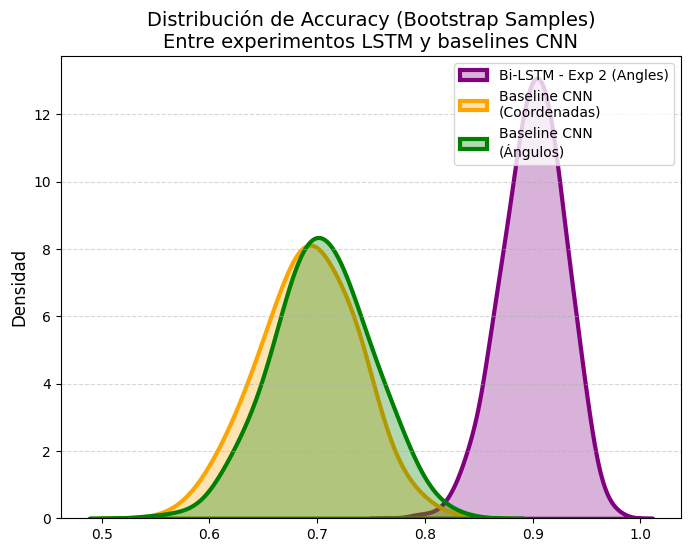

In [24]:
# Nos quedamos con el mejor experimento LSTM
best_lstm_exp = ba_exp_bi_lstm_02
best_lstm_name = nombres_legibles_lstm['EXP-Bi-LSTM-02']

# Comparamos con los baseline CNNs
# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(best_lstm_exp, color='purple', lw=3, label=best_lstm_name, bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_01, color='orange', lw=3, label=nombres_legibles['EXP-CNN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_02, color='green', lw=3, label=nombres_legibles['EXP-CNN-02'], bw_adjust=1.5, fill=True, alpha=0.3)
plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre experimentos LSTM y baselines CNN', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Visualmente, las curvas de densidad confirman que en el caso del análisis sin aumento de datos, la LSTM bidireccional obtiene mejores resultados que ambas arquitecturas de redes convolucionales, que se quedaron rondando el 70% de precisión. Observamos que el modelo EXP-Bi-LSTM-02 (con ángulos articulares) alcanzó un valor de aproximadamente 0.9, superando con creces las puntuaciones de los modelos baseline y demostrando que la naturaleza secuencial y direccional de las RNN es superior para la clasificación de movimientos complejos en este contexto. 

## C. Resultados con un Modelado Espacio-Temporal Avanzado (ST-GCN)
*¿Un modelo híbrido avanzado conseguirá mejores puntuaciones que las LSTM?*

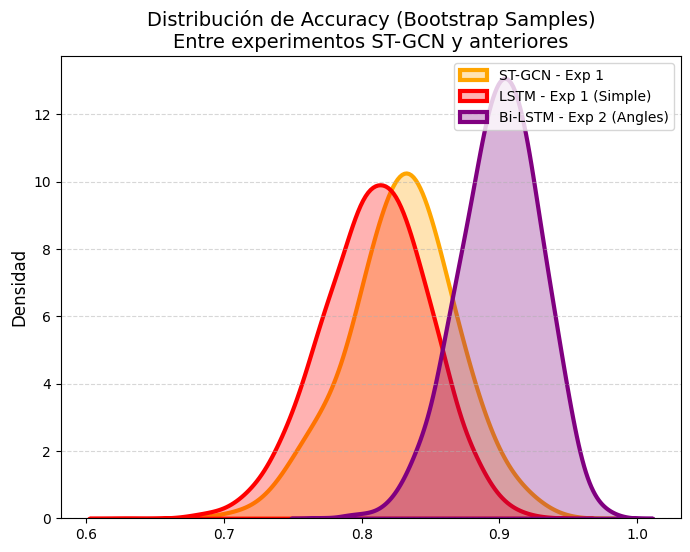

In [25]:
ba_exp_st_gcn_01 = np.load('../results/bootstrap_accuracies_exp_st_gcn_01.npy')

nombres_legibles_st_gcn = {
    'EXP-ST-GCN-01': 'ST-GCN - Exp 1',

}

# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(ba_exp_st_gcn_01, color='orange', lw=3, label=nombres_legibles_st_gcn['EXP-ST-GCN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_lstm_01, color='red', lw=3, label=nombres_legibles_lstm['EXP-LSTM-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(best_lstm_exp, color='purple', lw=3, label=best_lstm_name, bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre experimentos ST-GCN y anteriores', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

La ST-GCN no ha aportado mejores resultados que los ya encontrado. El entrenamiento de este modelo ha supuesto mayores costes computacionales (con uso de GPU) que las anteriores arquitecturas y las diferencias en accuracy respecto al uso de una LSTM simple (entrenada con datos de coordenadas en bruto) son mínimas.

## D. Evaluación de Robustez (Data Augmentation)
Comparamos los modelos entrenados con datos originales y con datos augmentados.

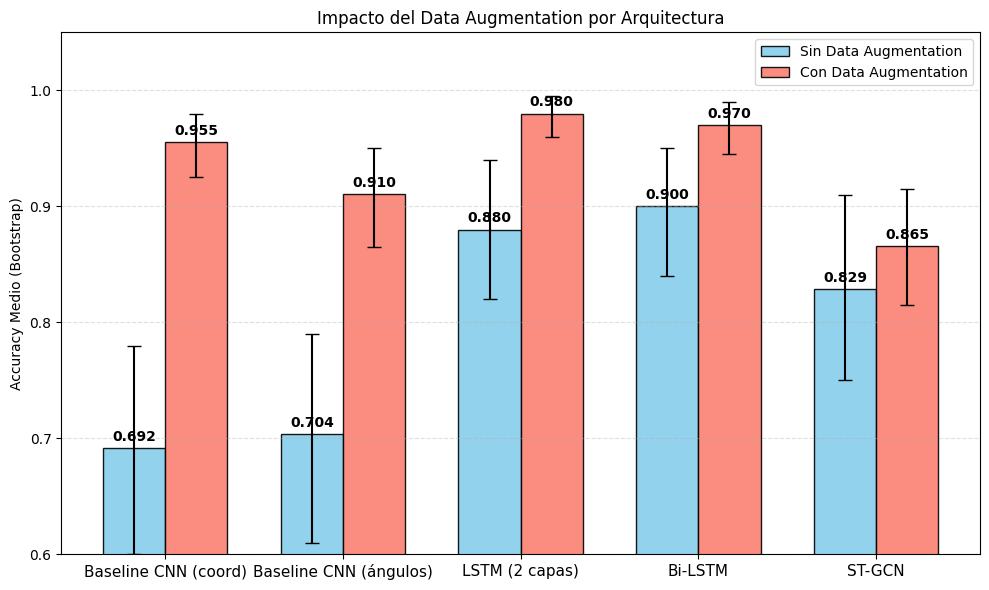

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# CONFIGURACIÓN DE PAREJAS A COMPARAR
pares_comparativa = [
    # (Etiqueta Eje X,      ID Original,   ID Aumentado)
    ('Baseline CNN (coord)',       'EXP-CNN-01',  'EXP-CNN-03'), 
    ('Baseline CNN (ángulos)',     'EXP-CNN-02',  'EXP-CNN-04'),
    ('LSTM (2 capas)',             'EXP-LSTM-02', 'EXP-LSTM-04'), 
    ('Bi-LSTM',                    'EXP-Bi-LSTM-02', 'EXP-Bi-LSTM-04'),
    ('ST-GCN',                     'EXP-ST-GCN-01', 'EXP-ST-GCN-02'),
    
]

# Listas para guardar los datos a graficar
nombres = []
means_orig, err_down_orig, err_up_orig = [], [], []
means_aug,  err_down_aug,  err_up_aug  = [], [], []

# EXTRACCIÓN DE DATOS DEL DATAFRAME
for nombre, id_orig, id_aug in pares_comparativa:
    nombres.append(nombre)
    
    # Datos sin Augmentación 
    row_orig = df_resultados[df_resultados['ID Exp.'] == id_orig]
    if not row_orig.empty:
        mu = row_orig['Acc. Medio'].values[0]
        lower = row_orig['IC Inf (95%)'].values[0]
        upper = row_orig['IC Sup (95%)'].values[0]
        
        means_orig.append(mu)
        
        err_down_orig.append(mu - lower)
        err_up_orig.append(upper - mu)
    else:
        # Si no existe el dato, rellenamos con 0 para que no falle el gráfico
        means_orig.append(0); err_down_orig.append(0); err_up_orig.append(0)

    # Datos con aumentación 
    row_aug = df_resultados[df_resultados['ID Exp.'] == id_aug]
    if not row_aug.empty:
        mu = row_aug['Acc. Medio'].values[0]
        lower = row_aug['IC Inf (95%)'].values[0]
        upper = row_aug['IC Sup (95%)'].values[0]
        
        means_aug.append(mu)
        err_down_aug.append(mu - lower)
        err_up_aug.append(upper - mu)
    else:
        means_aug.append(0); err_down_aug.append(0); err_up_aug.append(0)

# PREPARACIÓN DEL GRÁFICO
x = np.arange(len(nombres)) # Posiciones en el eje X (0, 1, 2...)
width = 0.35 # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

yerr_orig = [err_down_orig, err_up_orig]
yerr_aug  = [err_down_aug, err_up_aug]

# Graficamos el diagrama de barras
rects1 = ax.bar(x - width/2, means_orig, width, yerr=yerr_orig, 
                label='Sin Data Augmentation', capsize=5, 
                color='skyblue', edgecolor='black', alpha=0.9)

rects2 = ax.bar(x + width/2, means_aug, width, yerr=yerr_aug, 
                label='Con Data Augmentation', capsize=5, 
                color='salmon', edgecolor='black', alpha=0.9)


ax.set_ylabel('Accuracy Medio (Bootstrap)')
ax.set_title('Impacto del Data Augmentation por Arquitectura')
ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylim(0.6, 1.05) # Ajustar zoom según tus datos reales
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Función auxiliar para poner etiquetas encima de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Solo etiquetamos si hay dato
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

Al analizar el gráfico de barras, salta a la vista que la introducción de la aumentación de datos provoca un salto drástico en el rendimiento, con barras que rozan la perfección y unos intervalos de confianza minúsculos. Sin embargo, estos resultados tan idealistas nos generan serias dudas sobre su validez real. A pesar de haber mantenido estrictamente las secuencias aumentadas en el mismo fold que las originales, sospechamos que ha existido una fuga de información: es muy probable que la obtención de landmarks (en vez del uso de imágenes de vídeo) no sea suficiente para enmascarar la 'firma de movimiento' única de cada sujeto. Es posible que los modelos hayan podido identificar a la persona que ejecuta la flexión y clasificarla por memorización de sus movimientos o estilo de ejecución particular, en lugar de aprender las características biomecánicas generales de una buena ejecución.